In [13]:
# Cell 1: 导入库
import numpy as np
import torch
import torchvision.transforms as transforms
import onnxruntime as ort
from PIL import Image
import matplotlib.pyplot as plt
import time

In [15]:
print("Available providers:", ort.get_available_providers())
if 'CUDAExecutionProvider' in ort.get_available_providers():
    print("✓ GPU support is available!")
else:
    print("✗ GPU support not available. Check CUDA installation.")

Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✓ GPU support is available!


In [17]:
# Cell 2: 加载 ONNX 模型
providers = [
    ('CUDAExecutionProvider', {
        'device_id': 0,           # Use first GPU
        'gpu_mem_limit': 2 * 1024 * 1024 * 1024,  # 2GB memory limit
        'arena_extend_strategy': 'kNextPowerOfTwo',
    }),
    'CPUExecutionProvider'        # Fallback to CPU if GPU fails
]
ort_session = ort.InferenceSession("mnist_model.onnx", providers=providers)
print(f"ONNX Runtime 可用 Provider: {ort_session.get_providers()}")

ONNX Runtime 可用 Provider: ['CUDAExecutionProvider', 'CPUExecutionProvider']


In [18]:
# Cell 3: 准备测试图片（和之前一样）
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((28, 28))
    img_tensor = transforms.ToTensor()(img)
    img_tensor = transforms.Normalize((0.1307,), (0.3081,))(img_tensor)
    return img_tensor.numpy()  # ONNX Runtime 需要 numpy 数组

In [28]:
# Cell 4: 用 ONNX Runtime 推理
image_path = "my_digit.png"  # 你自己的手写数字
input_data = preprocess_image(image_path)
input_data = input_data.reshape(1, 1, 28, 28).astype(np.float32)

# 推理
outputs = ort_session.run(["output"], {"input": input_data})
# print(outputs)
predicted_label = np.argmax(outputs[0])

print(f"ONNX Runtime 预测结果: {predicted_label}")

[array([[-2.3320775, -2.6271179, -2.3124232, -2.5134287, -2.2279382,
        -2.3934612, -2.523386 , -2.486307 , -1.7525077, -2.164545 ]],
      dtype=float32)]
ONNX Runtime 预测结果: 8


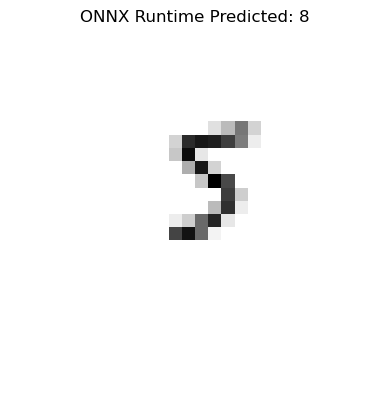

In [20]:
# Cell 5: 显示图片（可选）
img = Image.open(image_path).convert('L').resize((28, 28))
plt.imshow(img, cmap='gray')
plt.title(f"ONNX Runtime Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [8]:
import torch.nn as nn
import torch.nn.functional as F

In [9]:
# Cell 2: 定义模型（和之前一样）
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [27]:
# Cell 6: 速度对比
import time

# 准备一批测试数据（100张图）
test_image = preprocess_image("my_digit.png")
test_input = test_image.reshape(1, 1, 28, 28).astype(np.float32)

# PyTorch 推理速度
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
model.load_state_dict(torch.load('mnist_model.pth', map_location=device, weights_only=False))
model.eval()

torch_input = torch.from_numpy(test_input).to(device)

# 预热
with torch.no_grad():
    _ = model(torch_input)

# 计时
start = time.time()
for _ in range(100):
    with torch.no_grad():
        _ = model(torch_input)
torch_time = (time.time() - start) / 100 * 1000  # 转为毫秒
print(f"PyTorch 平均推理时间: {torch_time:.3f} ms")

# ONNX Runtime 推理速度
# 预热
_ = ort_session.run(["output"], {"input": test_input})

start = time.time()
for _ in range(100):
    _ = ort_session.run(["output"], {"input": test_input})
ort_time = (time.time() - start) / 100 * 1000
print(f"ONNX Runtime 平均推理时间: {ort_time:.3f} ms")

print(f"加速比: {torch_time / ort_time:.2f}x")

PyTorch 平均推理时间: 0.560 ms
ONNX Runtime 平均推理时间: 0.360 ms
加速比: 1.56x


## 基础理解（应该能立即回答）
### ONNX Runtime 和 PyTorch 在推理时有什么本质区别？为什么 ONNX Runtime 可能更快？
- 我的理解是ONNX Runtime只包含了模型的最核心的信息，可能省略了一些不重要的参数和layer，所以会比pytorch快。
- 部分正确，但真正原因是图优化和算子融合
- 图优化：合并连续的操作（如 Conv + BN + ReLU 融合成一个算子）
- 内存复用：减少内存分配开销
- 多线程调度：更高效的执行计划
- 算子库优化：针对不同硬件优化的实现
### 你导出的 mnist_model.onnx 文件里包含了什么信息？它和 .pth 文件有什么不同？
- .onnx文件是一个通用的文件，可以在不同的硬件和架构中使用，.pth是pytorch专用的格式。
### 为什么在 ONNX Runtime 推理前需要把输入从 torch.Tensor 转成 numpy 数组？
- 因为.onnx是通用格式，只接受numpy数组。
## 动手验证（需要运行代码或改参数）
### 把 ONNX Runtime 的 providers 改成 ['CPUExecutionProvider']，推理速度会变吗？为什么？
- 会变。我尝试了使用CUDAExecutionProvider，结果发现速度反而变慢了。当使用一个更模拟现实场景的输入的时候可能用gpu就会性能更突出一些。
- 这很正常。因为 MNIST 模型太小，GPU 的启动开销（kernel launch latency）比计算本身还大。对于大模型（如 ResNet50），GPU 加速比会显著提升（10x+）。
### 对比 PyTorch 和 ONNX Runtime 的推理结果，它们的输出是否完全一致（小数点后4位）？如果不一样，可能是什么原因？
- 不一致，可能是因为计算方式和保留的精度不一致导致的。
### 把 mnist_model.onnx 重命名后重新加载，会发生什么错误？这个错误说明了什么？
- 说明文件需要修改的话需要重新导出。
## 深入思考（面试可能会问）
### ONNX Runtime 支持 GPU 加速吗？需要什么条件？你现在的环境能用吗？
- 支持，需要安装onnxruntime-gpu包以及相对应的cuda包。我的硬件支持在gpu上跑，并且进行了测试。
### 如果一个模型包含 if 语句（依赖输入数据的动态分支），导出 ONNX 时可能会遇到什么问题？如何解决？
- 导出时可能导致if条件句丢失。
- 解决方案：用 torch.jit.script 或改写为向量化代码
### 你测出的加速比是多少？如果换一个更大的模型（如 ResNet50），加速比会变大还是变小？为什么？
- 用cpu的时候测出来的是3x，用gpu的时候测出来的是1.8x。如果模型更大的话我觉得加速比会变小，因为通用模型会比pytorch专用的模型的计算更复杂一些。
- 纠正：更大模型的加速比会变大，不是变小。
- 原因：

小模型（如 MNIST）：计算量小，GPU 启动开销占比大 → 加速比小（1.5-2x）

大模型（如 ResNet50）：计算量大，GPU 并行优势充分发挥 → 加速比大（5-10x）

超大模型（如 BERT、LLM）：GPU 加速比可达 20-50x

你测的 1.56x 是正常的，因为模型太小。换 ResNet50 后，加速比可能会到 5-10x。